In [2]:
from google.colab import files
uploaded = files.upload()

Saving WorldCupMatches_cleaned.csv to WorldCupMatches_cleaned.csv
Saving WorldCups_Cleaned.csv to WorldCups_Cleaned.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('WorldCupMatches_cleaned.csv')
cups = pd.read_csv('WorldCups_Cleaned.csv')

In [4]:
matches.dtypes
cups.dtypes


,0
year,int64
country,object
winner,object
runners_up,object
third,object
fourth,object
goalsscored,int64
qualifiedteams,int64
matchesplayed,int64
attendance,int64


In [5]:
matches['datetime'] = pd.to_datetime(matches['datetime'])

In [6]:
matches['attendance'] = matches['attendance'].astype('int')

In [7]:
matches.describe()

,year,datetime,home_team_goals,away_team_goals,attendance,half-time_home_goals,half-time_away_goals,roundid,matchid
count,836.000000,836,836.000000,836.000000,836.000000,836.000000,836.000000,8.360000e+02,8.360000e+02
mean,1984.535885,1985-01-01 20:22:19.593301440,1.824163,1.021531,44855.533493,0.718900,0.427033,1.086093e+07,5.677577e+07
min,1930.000000,1930-07-13 15:00:00,0.000000,0.000000,2000.000000,0.000000,0.000000,2.010000e+02,2.500000e+01
25%,1970.000000,1970-06-06 16:00:00,1.000000,0.000000,29800.000000,0.000000,0.000000,2.620000e+02,1.183500e+03
50%,1990.000000,1990-06-10 21:00:00,2.000000,1.000000,41061.500000,0.000000,0.000000,3.370000e+02,2.113500e+03
75%,2002.000000,2002-06-14 20:30:00,3.000000,2.000000,60984.500000,1.000000,1.000000,2.497220e+05,4.395005e+07
max,2014.000000,2014-07-13 16:00:00,10.000000,7.000000,173850.000000,6.000000,5.000000,9.741060e+07,3.001865e+08
std,22.299860,NaN,1.619178,1.072024,23537.274659,0.941995,0.675091,2.751802e+07,1.070329e+08


In [8]:
cups.describe()

,year,goalsscored,qualifiedteams,matchesplayed,attendance
count,20.000000,20.000000,20.000000,20.000000,2.000000e+01
mean,1974.800000,118.950000,21.250000,41.800000,1.872882e+06
std,25.582889,32.972836,7.268352,17.218717,1.071842e+06
min,1930.000000,70.000000,13.000000,17.000000,3.630000e+05
25%,1957.000000,89.000000,16.000000,30.500000,8.748315e+05
50%,1976.000000,120.500000,16.000000,38.000000,1.734864e+06
75%,1995.000000,145.250000,26.000000,55.000000,2.725173e+06
max,2014.000000,171.000000,32.000000,64.000000,3.587538e+06


In [9]:
cups

,year,country,winner,runners_up,third,fourth,goalsscored,qualifiedteams,matchesplayed,attendance
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590549
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363000
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375700
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22,1045246
4,1954,Switzerland,Germany FR,Hungary,Austria,Uruguay,140,16,26,768607
5,1958,Sweden,Brazil,Sweden,France,Germany FR,126,16,35,819810
6,1962,Chile,Brazil,Czechoslovakia,Chile,Yugoslavia,89,16,32,893172
7,1966,England,England,Germany FR,Portugal,Soviet Union,89,16,32,1563135
8,1970,Mexico,Brazil,Italy,Germany FR,Uruguay,95,16,32,1603975
9,1974,Germany,Germany FR,Netherlands,Poland,Brazil,97,16,38,1865753


###**1. Univariate Analysis**

Attendance Column

Histogram

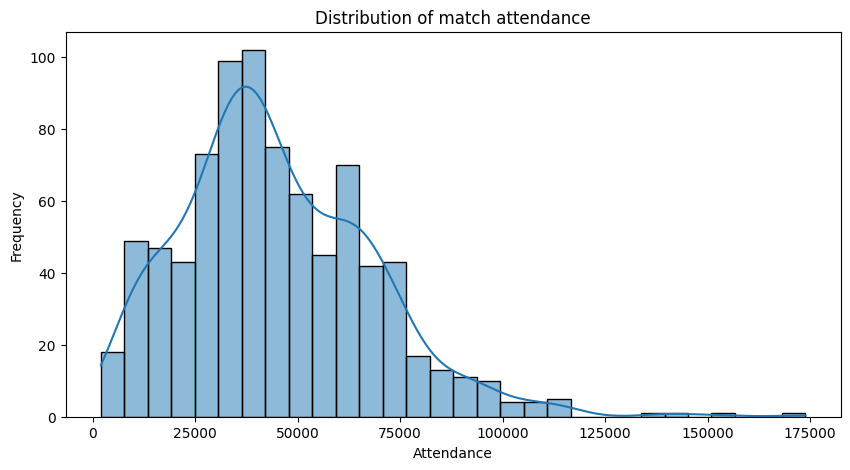

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(matches['attendance'] , bins=30 , kde=True)
plt.title('Distribution of match attendance')
plt.xlabel('Attendance')
plt.ylabel('Frequency')
plt.show()

Boxplot

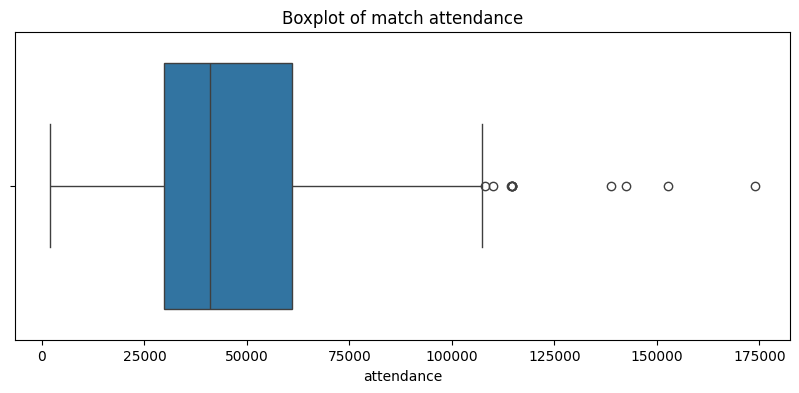

In [11]:
plt.figure(figsize=(10,4))
sns.boxplot(x=matches['attendance'])
plt.title('Boxplot of match attendance')
plt.show()

Goals

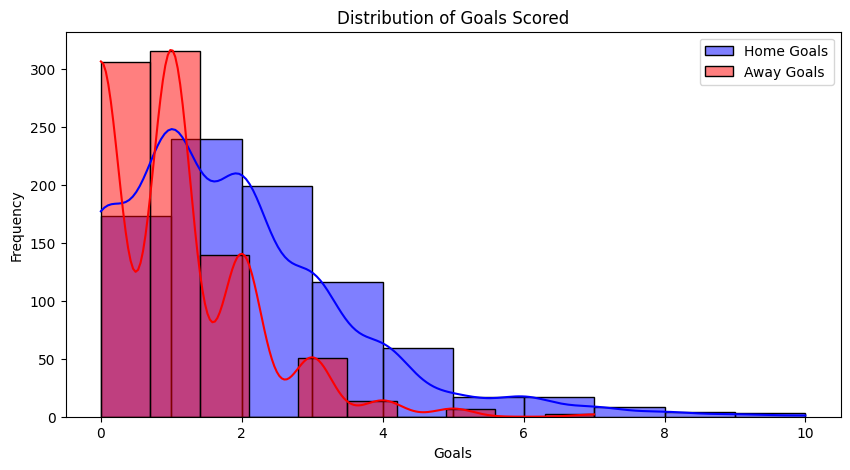

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(matches['home_team_goals'], bins=10, kde=True, color='blue', label='Home Goals')
sns.histplot(matches['away_team_goals'], bins=10, kde=True, color='red', label='Away Goals')
plt.title('Distribution of Goals Scored')
plt.xlabel('Goals')
plt.ylabel('Frequency')
plt.legend()
plt.show()

###**2. Bivariate Analysis**

In [13]:
cups.corr(numeric_only=True)

,year,goalsscored,qualifiedteams,matchesplayed,attendance
year,1.000000,0.829886,0.895565,0.972473,0.953158
goalsscored,0.829886,1.000000,0.866201,0.876201,0.774670
qualifiedteams,0.895565,0.866201,1.000000,0.949164,0.875360
matchesplayed,0.972473,0.876201,0.949164,1.000000,0.933243
attendance,0.953158,0.774670,0.875360,0.933243,1.000000


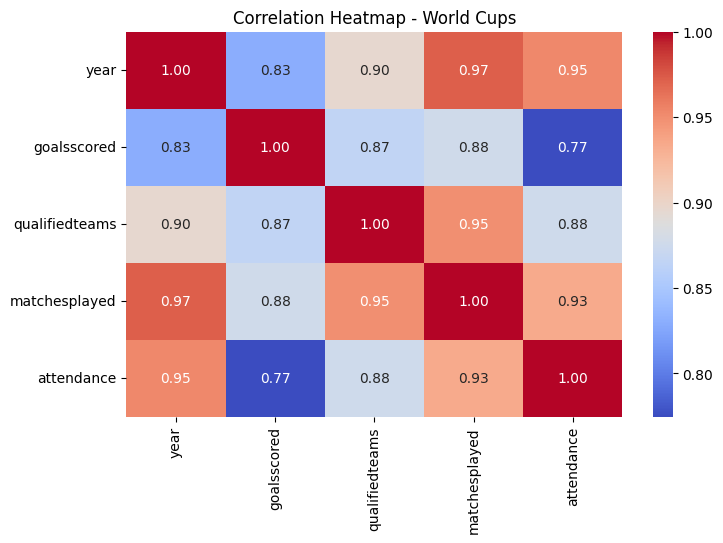

In [14]:
plt.figure(figsize=(8,5))
sns.heatmap(cups.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Heatmap - World Cups')
plt.show()

Team performance analysis

In [32]:
cups['winner'].value_counts()



,count
winner,
Brazil,5
Italy,4
Germany,4
Uruguay,2
Argentina,2
England,1
France,1
Spain,1


In [16]:
cups['winner'] = cups['winner'].str.replace('Germany FR', 'Germany')


In [17]:
cols =  ['runners_up','third','fourth']
for col in cols:
  cups[col] = cups[col].str.replace('Germany FR', 'Germany')

In [18]:
matches['home_team_name'] = matches['home_team_name'].str.replace('Germany FR', 'Germany')
matches['away_team_name'] = matches['away_team_name'].str.replace('Germany FR', 'Germany')

/tmp/ipykernel_1108/3139937539.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_home_teams.values , y=top_home_teams.index , palette='viridis')


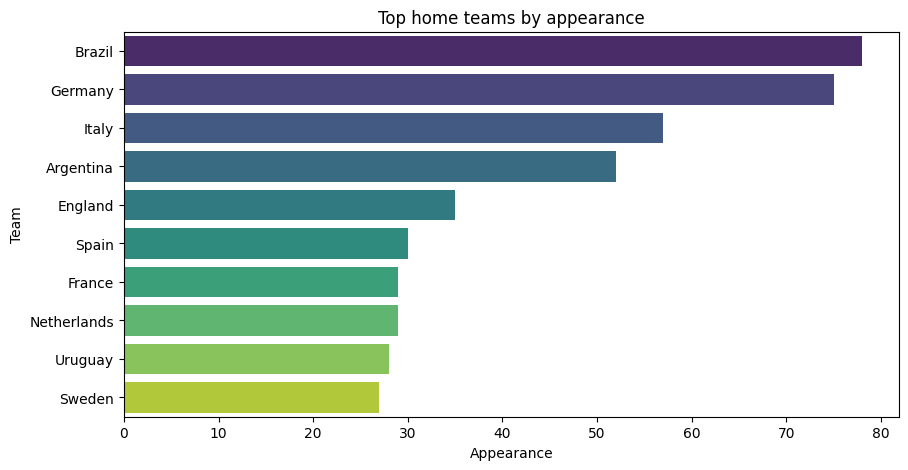

In [19]:
top_home_teams = matches['home_team_name'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_home_teams.values , y=top_home_teams.index , palette='viridis')
plt.title('Top home teams by appearance')
plt.xlabel('Appearance')
plt.ylabel('Team')
plt.show()

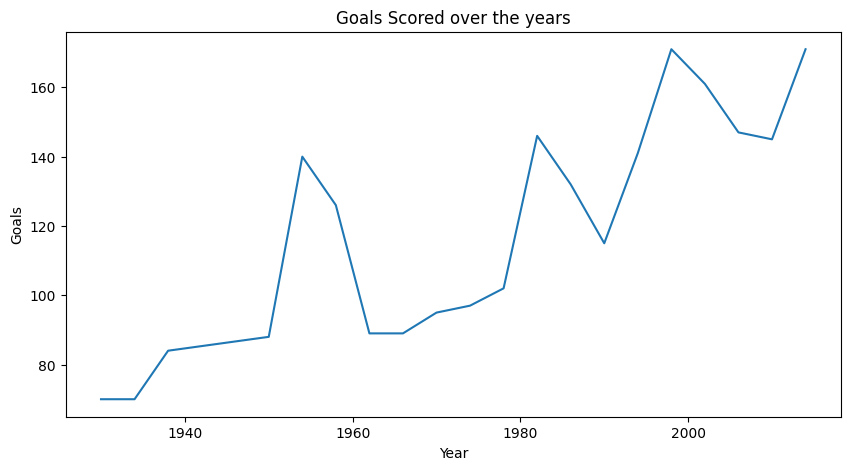

In [20]:
plt.figure(figsize=(10,5))
sns.lineplot(data=cups,x='year',y='goalsscored')
plt.title('Goals Scored over the years')
plt.xlabel('Year')
plt.ylabel('Goals')
plt.show()

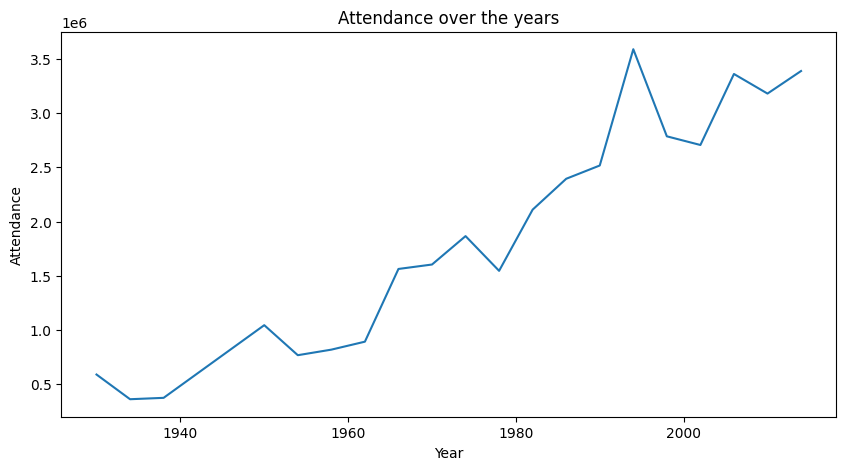

In [21]:
plt.figure(figsize=(10,5))
sns.lineplot(data=cups,x='year',y='attendance')
plt.title('Attendance over the years')
plt.xlabel('Year')
plt.ylabel('Attendance')
plt.show()


In [22]:
matches['home_team_goals'].value_counts()

,count
home_team_goals,
1,240
2,199
0,173
3,116
4,59
5,17
6,17
7,8
8,4


Total Goals of a team

In [30]:
hoam_goals = matches.groupby('home_team_name')['home_team_goals'].sum()
away_goals = matches.groupby('away_team_name')['away_team_goals'].sum()
total_goals = hoam_goals.add(away_goals, fill_value=0)
total_goals = total_goals.sort_values(ascending=False).head(10)

/tmp/ipykernel_1108/1407309366.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_goals.head(10).values,y=total_goals.head(10).index,palette='viridis')


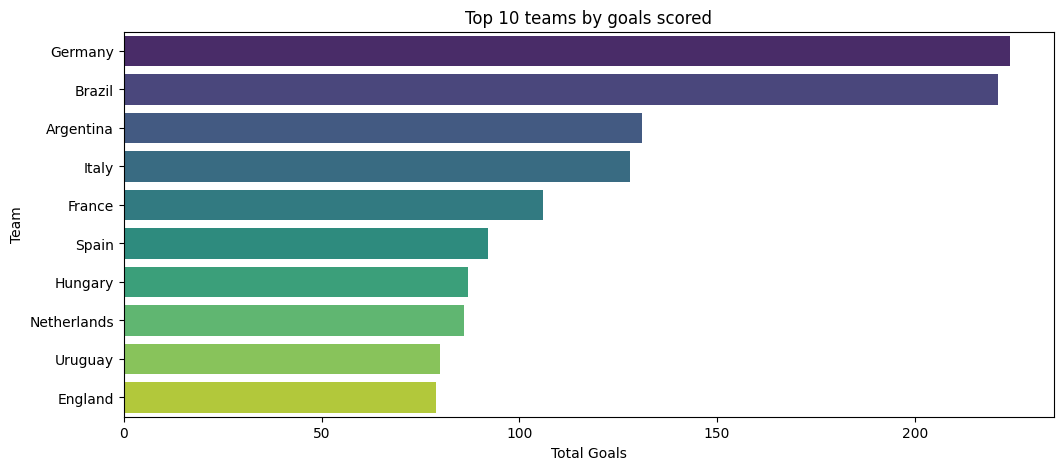

In [31]:
plt.figure(figsize=(12,5))
sns.barplot(x=total_goals.head(10).values,y=total_goals.head(10).index,palette='viridis')
plt.title('Top 10 teams by goals scored')
plt.xlabel('Total Goals')
plt.ylabel('Team')
plt.show()

# EDA Summary — FIFA World Cup Dataset

## 1. Dataset Overview
- **WorldCupMatches** — 836 matches × 20 columns covering
  all World Cup matches from 1930 to 2014
- **WorldCups** — 20 tournaments × 10 columns covering
  tournament-level statistics

## 2. Data Cleaning & Preparation
- Converted `datetime` column from object to proper datetime type
- Converted `attendance` from float to integer
- Fixed historical naming issue — **Germany FR** replaced with
  **Germany** across all columns in both datasets

## 3. Descriptive Statistics
- Average home goals = **1.82**, average away goals = **1.02**
  → confirms home advantage
- Attendance is **right skewed** — mean (44,855) > median (41,061),
  meaning a few high attendance matches pull the average up
- Max attendance ever = **173,850** (1950 World Cup final)

## 4. Univariate Analysis
- Most matches had attendance between **25,000 to 50,000**
- Away teams scored **0 or 1 goals** most frequently
- Home teams scored **1 or 2 goals** most frequently
- → **Home advantage is clearly visible in the data**

## 5. Correlation Analysis
- Strongest correlation → **year vs matchesplayed (0.97)**
  — more recent tournaments had more matches
- **Goalsscored vs matchesplayed (0.88)** — more matches
  means more goals, not just better attacking play
- Weakest correlation → **goalsscored vs attendance (0.77)**
  — crowd size doesn't directly influence goals

## 6. Team Performance Analysis
- **Brazil** won the most World Cups (5 titles)
- **Germany** scored the most total goals (224)
  narrowly ahead of Brazil (221)
- Clear 3 tier system exists:
  - Tier 1 → Germany, Brazil (consistent dominance)
  - Tier 2 → Argentina, Italy
  - Tier 3 → France, Spain, Netherlands, England

## 7. Trends Over Time
- Goals scored show an **overall upward trend** with dips in
  1962 and 1990 due to defensive tactics
- Attendance **steadily grew** with a drop around 1938
  due to WW2 tensions
- Major spike in **1994** when USA hosted — record 3.6M attendance
  and FIFA expanded to 32 teams

## 8. Conclusion
The data reveals that **Germany and Brazil** are the most dominant
nations in World Cup history. Home advantage is statistically
proven through goals data. Tournament growth over time is directly
linked to expansion of qualified teams and host country
stadium capacity.




